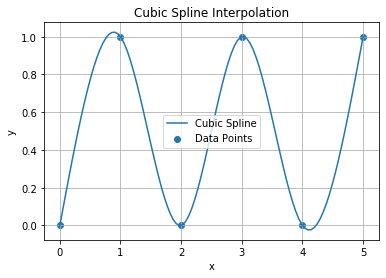

In [17]:
import numpy as np
import matplotlib.pyplot as plt


# Thomas algorithm function provided in slides
def thomas_algorithm( a, b, c, d ):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


# Algorithm for setting up tridiagonal matrix 
def setup_tridiagonal_matrix( x, y ):
    h = np.diff(x)  # step sizes
    A = []
    B = []
    C = []
    D = []
    for i in range( 1, len(x) - 1 ):
        left_slope = (y[i] - y[i-1]) / h[i-1]
        right_slope = (y[i+1] - y[i]) / h[i]
        A.append(h[i-1])
        B.append(2 * (h[i-1] + h[i]))
        C.append(h[i])
        D.append(6* (right_slope - left_slope))
    return A, B, C, D 
        

# Algorithm for solving spline at a point
def evaluate_spline(x, y, m, x_eval):
    # Find interval
    for i in range(len(x) - 1):
        if(x[i] <= x_eval <= x[i+1]):
            xL, xU = x[i], x[i+1]
            yL, yU = y[i], y[i+1]
            mL, mU = m[i], m[i+1]
            break
    h = xU - xL
    # Cubic spline formula
    term1 = mL * (xU - x_eval)**3 / (6 * h)
    term2 = mU * (x_eval - xL)**3 / (6 * h)
    term3 = (yL - mL * h**2 / 6) * (xU - x_eval) / h
    term4 = (yU - mU * h**2 / 6) * (x_eval - xL) / h
    total = term1 + term2 + term3 + term4
    return total
            
# Define known data points and setup tridiagonal system 
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
a, b, c, d = setup_tridiagonal_matrix(x, y)

# Evaluate spline over many points 
m_internal = thomas_algorithm(a, b, c, d)
m = np.concatenate(([0], m_internal, [0]))
x_eval = np.linspace(min(x), max(x), 100)
y_eval = []
for xi in x_eval:
    y_eval.append(evaluate_spline(x, y, m, xi))

# Plot the results
plt.scatter(x, y, marker='o', label='Data Points')
plt.plot(x_eval, y_eval, label='Cubic Spline')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()